In [4]:
from google.colab import files
uploaded = files.upload()

Saving part_1_ecommerce_customer_segmentation.csv to part_1_ecommerce_customer_segmentation (1).csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [8]:
df = pd.read_csv('part_1_ecommerce_customer_segmentation.csv')
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [9]:
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (4395, 9)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Category', 'Quantity',
       'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Category        object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object


In [10]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,67
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,208
Country,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4395 non-null   object 
 1   StockCode    4395 non-null   object 
 2   Description  4328 non-null   object 
 3   Category     4395 non-null   object 
 4   Quantity     4395 non-null   int64  
 5   InvoiceDate  4395 non-null   object 
 6   UnitPrice    4395 non-null   float64
 7   CustomerID   4187 non-null   object 
 8   Country      4395 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 309.2+ KB


In [12]:
df.describe()

,Quantity,UnitPrice
count,4395.000000,4395.000000
mean,2.826394,747.081477
std,3.846051,611.134932
min,-50.000000,-2244.520000
25%,1.000000,328.200000
50%,2.000000,544.320000
75%,4.000000,950.470000
max,50.000000,2939.580000


The dataset contains ecommerce transaction records with information about invoices, products, quantity purchased, prices, customers, and countries.

The dataset consists of 4395 rows and 9 columns.

Initial inspection revealed missing values in CustomerID and Description columns. Negative values were also present in Quantity and UnitPrice columns, indicating returns or data quality issues that require cleaning before analysis.

In [13]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,67
Category,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,208
Country,0


In [14]:
df = df.dropna(subset=['CustomerID'])

In [15]:
df.shape

(4187, 9)

In [16]:
df = df.dropna(subset=['Description'])

In [17]:
df.shape

(4123, 9)

In [18]:
(df['Quantity'] < 0).sum()

np.int64(183)

In [19]:
df = df[df['Quantity'] > 0]

In [20]:
(df['UnitPrice'] < 0).sum()

np.int64(20)

In [21]:
df = df[df['UnitPrice'] > 0]

In [22]:
df.duplicated().sum()


np.int64(31)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3848 entries, 0 to 4359
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3848 non-null   object        
 1   StockCode    3848 non-null   object        
 2   Description  3848 non-null   object        
 3   Category     3848 non-null   object        
 4   Quantity     3848 non-null   int64         
 5   InvoiceDate  3848 non-null   datetime64[ns]
 6   UnitPrice    3848 non-null   float64       
 7   CustomerID   3848 non-null   object        
 8   Country      3848 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 300.6+ KB


In [26]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [27]:
df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE,468.04
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE,248.30
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India,3645.60
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands,659.20
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands,526.21


In [28]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)

Data cleaning was performed to improve data quality.

- Removed rows with missing CustomerID values.
- Removed rows with missing product descriptions.
- Removed transactions with negative quantities.
- Removed transactions with negative unit prices.
- Removed duplicate records.
- Converted InvoiceDate to datetime format.
- Created a Revenue column by multiplying Quantity and UnitPrice.

In [29]:
customer_df = df.groupby('CustomerID').agg({
    'Revenue':'sum',
    'InvoiceNo':'nunique',
    'Quantity':'sum',
    'StockCode':'nunique',
    'Country':'first'
})

customer_df.columns = [
    'TotalRevenue',
    'PurchaseFrequency',
    'TotalQuantity',
    'UniqueProducts',
    'Country'
]

customer_df.head()

,TotalRevenue,PurchaseFrequency,TotalQuantity,UniqueProducts,Country
CustomerID,,,,,
C10001,22885.81,3,63,8,India
C10003,12061.04,1,10,3,United Kingdom
C10004,10579.97,2,16,5,United Kingdom
C10005,14154.57,2,17,7,Germany
C10006,27389.29,3,27,8,India


In [30]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
C10001,117,3,22885.81
C10003,33,1,12061.04
C10004,40,2,10579.97
C10005,297,2,14154.57
C10006,31,3,27389.29


In [31]:
rfm.describe()


,Recency,Frequency,Monetary
count,681.000000,681.000000,681.000000
mean,124.148311,2.027900,13414.205081
std,89.362826,1.099779,12575.661805
min,1.000000,1.000000,151.940000
25%,46.000000,1.000000,4674.950000
50%,111.000000,2.000000,9899.710000
75%,189.000000,3.000000,18165.600000
max,328.000000,7.000000,116064.960000


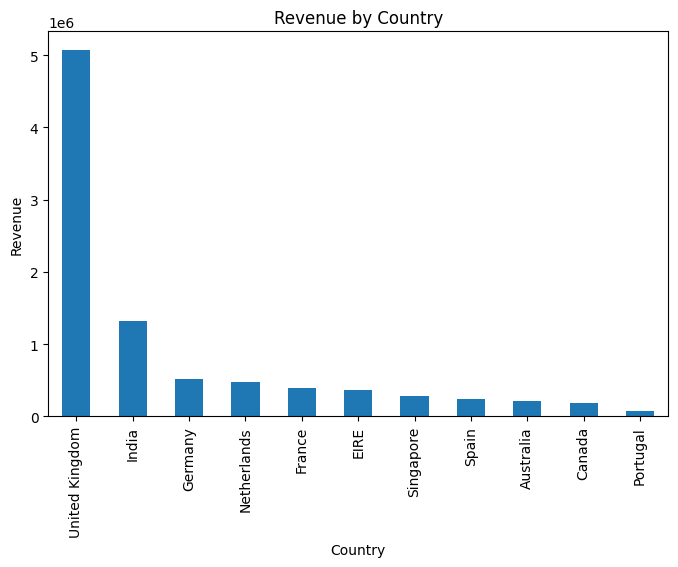

In [32]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')
plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.show()

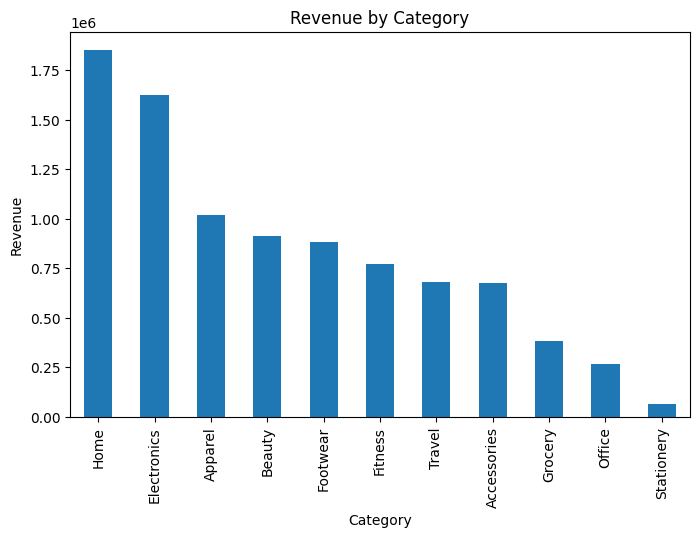

In [33]:
category_sales = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

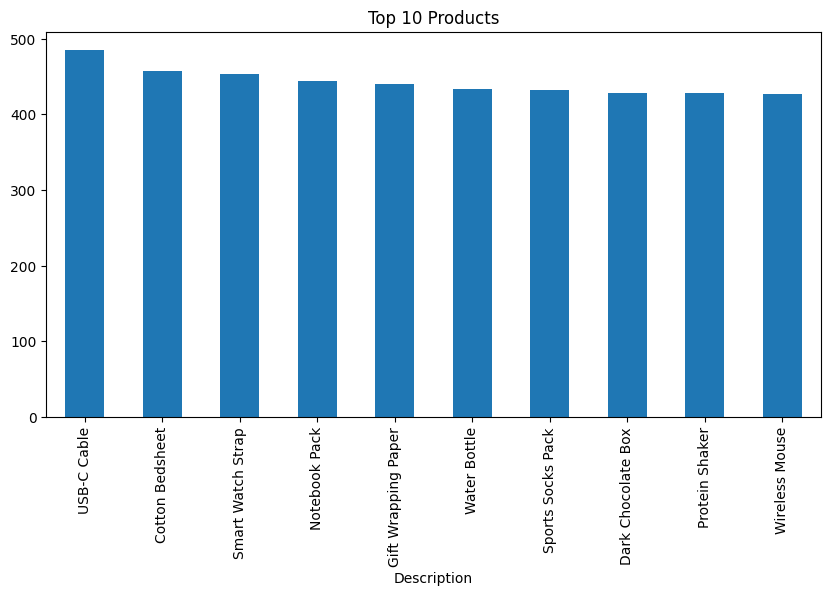

In [34]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency','Frequency','Monetary']]
)

In [36]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

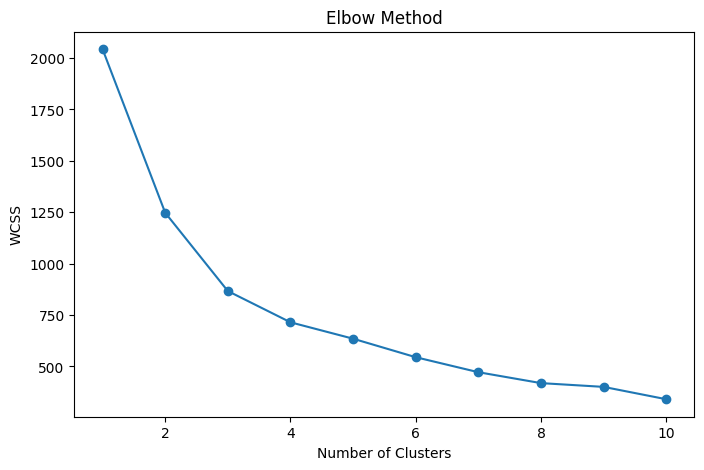

In [37]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [38]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
C10001,117,3,22885.81,0
C10003,33,1,12061.04,3
C10004,40,2,10579.97,3
C10005,297,2,14154.57,2
C10006,31,3,27389.29,0


In [39]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,72.055901,2.962733,18482.903851
1,75.838710,3.935484,41432.314839
2,232.423963,1.382488,8196.505207
3,73.883817,1.493776,7518.178382


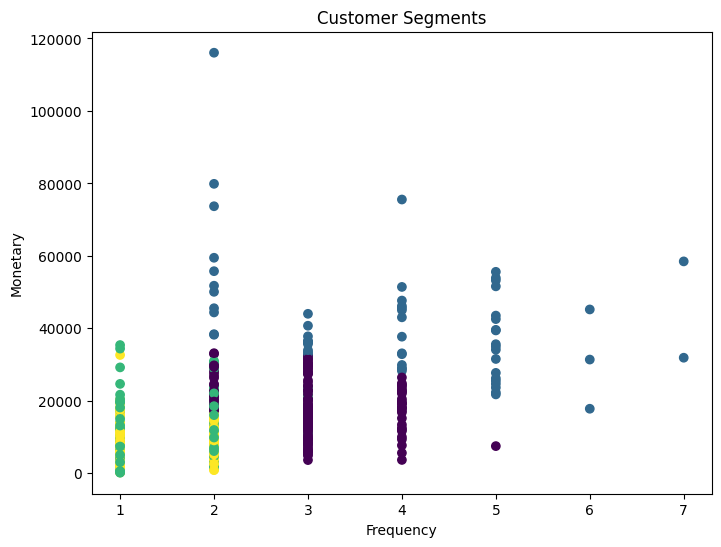

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments')
plt.show()

In [41]:
segment_map = {
    0: 'Loyal Customers',
    1: 'VIP Customers',
    2: 'Lost Customers',
    3: 'Occasional Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
C10001,117,3,22885.81,0,Loyal Customers
C10003,33,1,12061.04,3,Occasional Customers
C10004,40,2,10579.97,3,Occasional Customers
C10005,297,2,14154.57,2,Lost Customers
C10006,31,3,27389.29,0,Loyal Customers


In [42]:
rfm['Segment'] = rfm['Cluster'].map({
    0: 'Loyal Customers',
    1: 'VIP Customers',
    2: 'Lost Customers',
    3: 'Occasional Customers'
})

rfm['Segment'].value_counts()

,count
Segment,
Occasional Customers,241
Lost Customers,217
Loyal Customers,161
VIP Customers,62


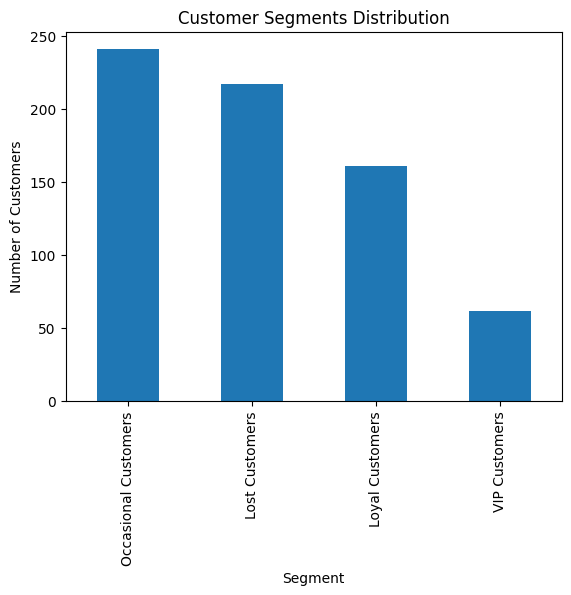

In [43]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()


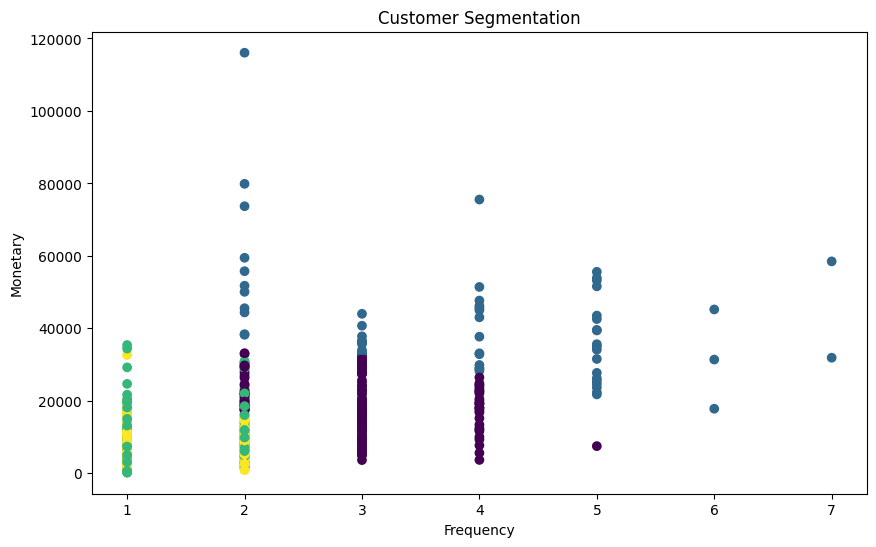

In [44]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")

plt.show()

In [45]:
rfm.to_csv("Customer_Segmentation_Result.csv")

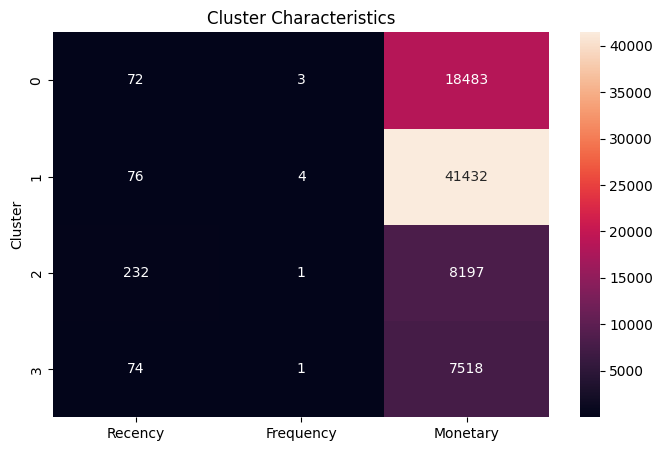

In [46]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(cluster_summary, annot=True, fmt='.0f')
plt.title("Cluster Characteristics")
plt.show()